In [1]:
import matplotlib.pyplot as plt

import numpy as np
import anndata as ad
import polars as pl
import sys

import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
early = ad.read_h5ad('private/data/clean_method/early.h5ad')
late = ad.read_h5ad('private/data/clean_method/late.h5ad')

In [10]:
var_i = np.intersect1d(late.var_names, early.var_names)
early=early[:,var_i]
late=late[:,var_i]

early.obs['batch'] = early.obs['batch'].to_numpy()
early.obs['timep'] = early.obs['timep'].to_numpy()


adata = ad.concat([early, late])
import pandas as pd
adata.obs['batch'] = pd.Categorical(adata.obs['batch'])
adata.obs['timep'] = pd.Categorical(adata.obs['timep'])
assert adata.shape[1] == late.shape[1]
adata.var = late.var.copy()
scit.tl.add_metadata(adata, ['acet', 'meth'])

/tmp/nix-shell-259770-0/ipykernel_282516/2464322822.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  early.obs['batch'] = early.obs['batch'].to_numpy()


Info: Added acet counts metadata
Info: Added meth counts metadata


In [ ]:
#adata = ad.read_h5ad('private/data/clean_method/combined_wt.h5ad')

In [20]:
np.random.seed(0)
print(scit.em.multiview_spectral(adata, ['acet', 'meth'], random_seed=22))
scit.tl.remove_pc(adata, 'X_multi_spectral', 0)

[1.         0.04389423 0.04230589 0.02448249 0.01821446 0.01524935
 0.01491402 0.01300932 0.01146833 0.01094636 0.01055557 0.0102452
 0.01012787 0.00998957 0.00988649 0.00974644 0.00964852 0.00958559
 0.00954769 0.00949553 0.00945079 0.00944093 0.0094014  0.00937616
 0.00933889]


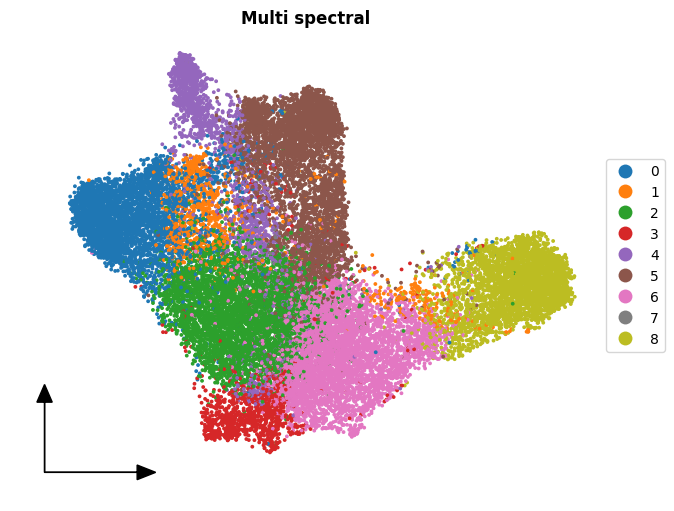

In [21]:
scit.em.umap(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.leiden(adata, 1, obsp_key='connectivities')
scit.set_defaults(figsize=(6,5))
scit.pl.embedding2d(adata, 'X_umap', 'leiden', title=f'Multi spectral')

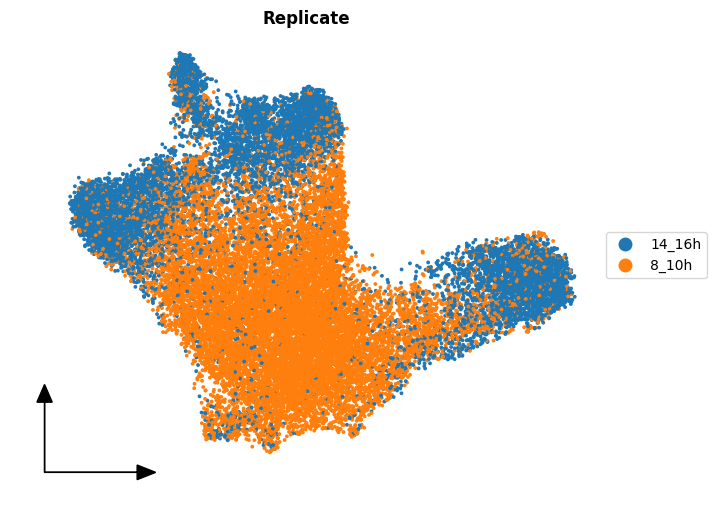

In [22]:
scit.pl.embedding2d(adata, 'X_umap', 'timep', title=f'Replicate')

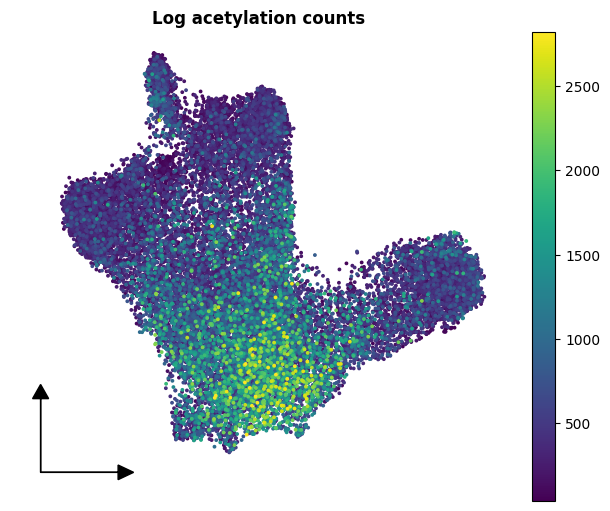

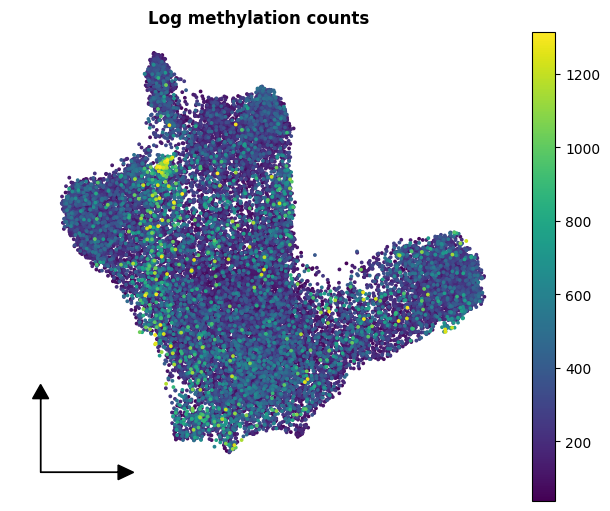

In [23]:
scit.pl.embedding2d(adata, 'X_umap', 'acet_total_counts', title='Log acetylation counts')
scit.pl.embedding2d(adata, 'X_umap', 'meth_total_counts', title='Log methylation counts')

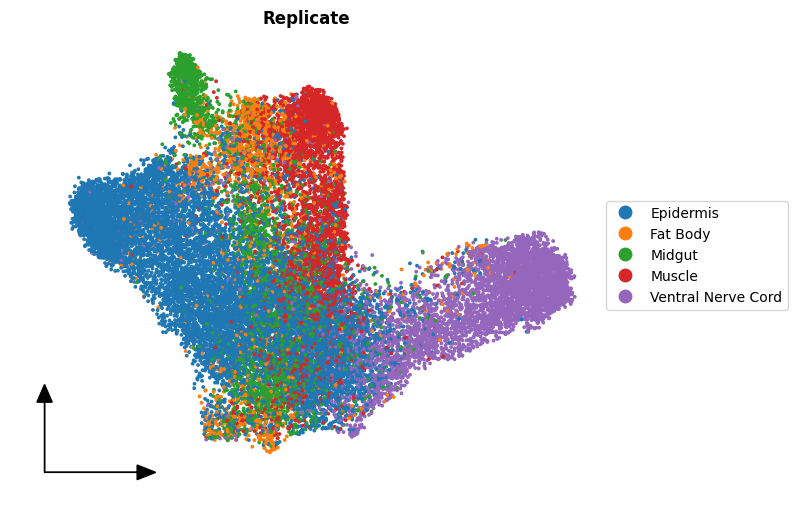

In [26]:
scit.pl.embedding2d(adata, 'X_umap', 'label', title=f'Replicate')

In [27]:
adata.write_h5ad('private/data/clean_method/combined_wt.h5ad')

In [ ]:
adata = ad.read_h5ad('private/data/clean_method/combined_wt.h5ad')

scit.pl.int.boxplot(
    
)